In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Objective of this notebook:
"What factors are most strongly associated with mathematics performance?"


#  **Data Preparation**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


In [4]:
case_study = pd.read_excel("/kaggle/input/datasets/yungkamlun/student-mat/student-mat.xlsx", sheet_name=0)

In [5]:
case_study.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

As we can see, there are no NULL elements in rows or columns, therefore, no cleaning is needed

In [6]:
case_study.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


# **Exploratory Analysis**

**Demographic factors (sex, address, age)**

In [7]:
case_study.describe()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


As we can see, the mean of the age is 16.696203 year old with max of 22 and min of 15.

In [8]:
case_study['sex'].value_counts()

sex
F    208
M    187
Name: count, dtype: int64

In [9]:
case_study['address'].value_counts()

address
U    307
R     88
Name: count, dtype: int64

**Academic factors (failures, studytime, schoolsup, paid)**

In [10]:
academic_factors = ['failures','studytime','schoolsup','paid']
for i in academic_factors:
    print(case_study[i].value_counts().sort_index())

failures
0    312
1     50
2     17
3     16
Name: count, dtype: int64
studytime
1    105
2    198
3     65
4     27
Name: count, dtype: int64
schoolsup
no     344
yes     51
Name: count, dtype: int64
paid
no     214
yes    181
Name: count, dtype: int64


**Attendance factors (absences)**

In [11]:
case_study['absences'].value_counts().sort_index()

absences
0     115
1       3
2      65
3       8
4      53
5       5
6      31
7       7
8      22
9       3
10     17
11      3
12     12
13      3
14     12
15      3
16      7
17      1
18      5
19      1
20      4
21      1
22      3
23      1
24      1
25      1
26      1
28      1
30      1
38      1
40      1
54      1
56      1
75      1
Name: count, dtype: int64

**Health factors (health, Dalc, Walc)**

In [12]:
Health_factor = ['health', 'Dalc', 'Walc']
for i in Health_factor:
    print(case_study[i].value_counts().sort_index())

health
1     47
2     45
3     91
4     66
5    146
Name: count, dtype: int64
Dalc
1    276
2     75
3     26
4      9
5      9
Name: count, dtype: int64
Walc
1    151
2     85
3     80
4     51
5     28
Name: count, dtype: int64


# **3. Visual Analysis**


# The distribution of each features

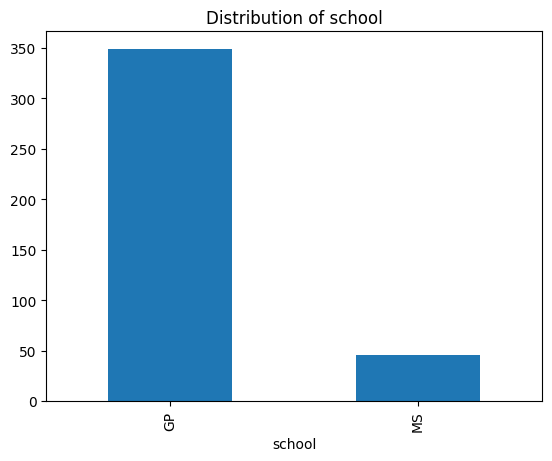

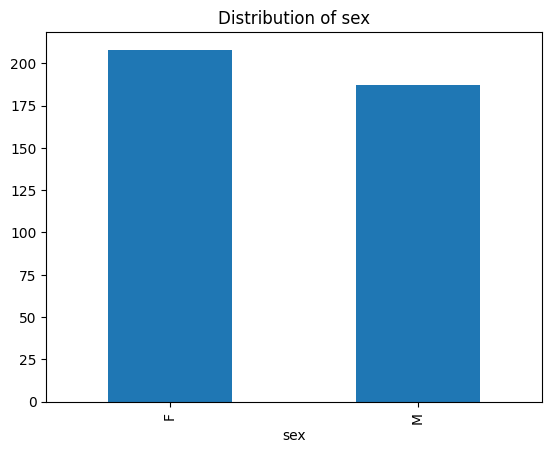

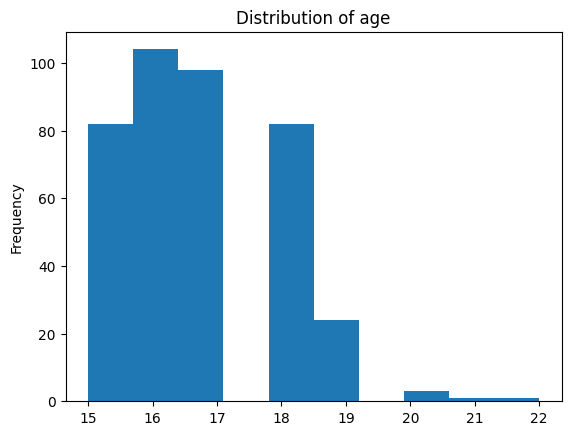

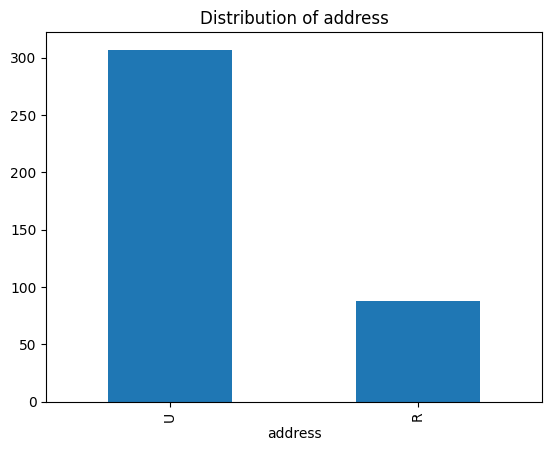

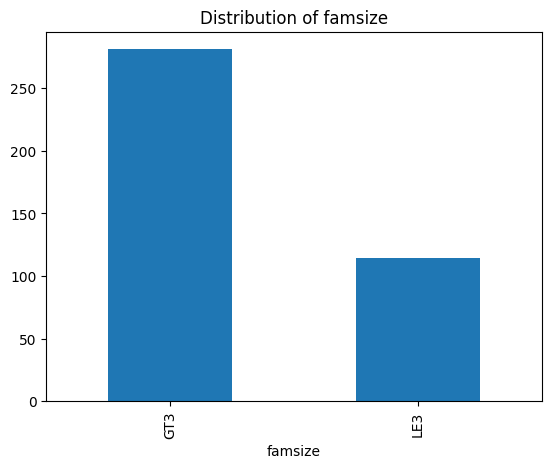

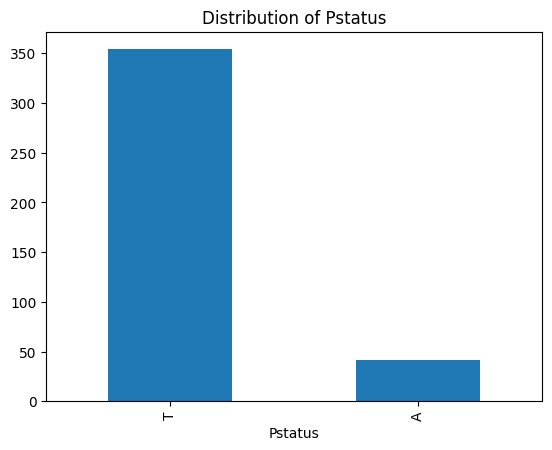

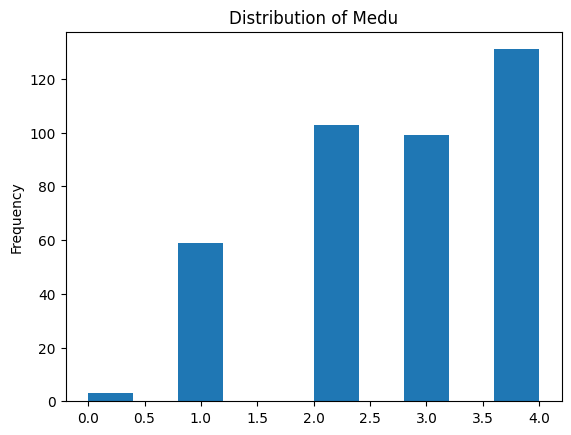

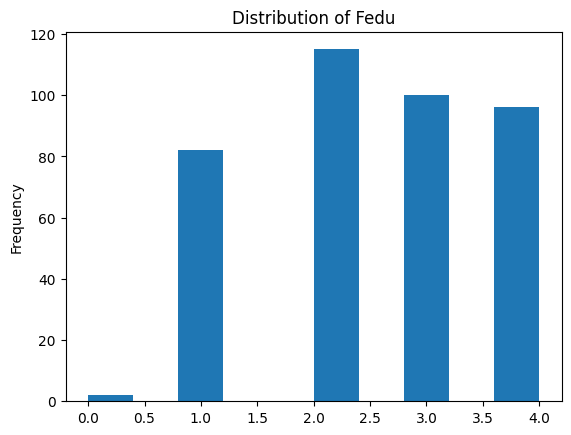

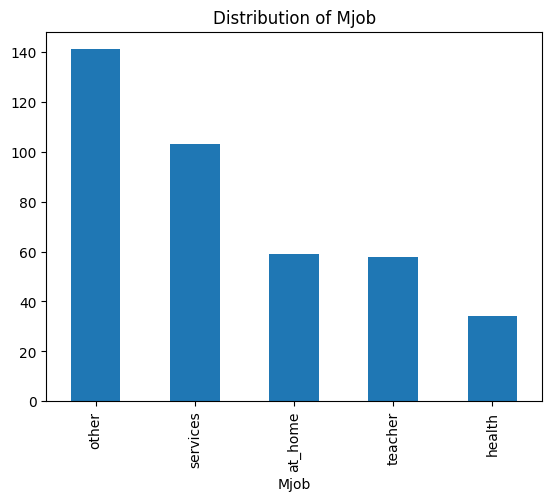

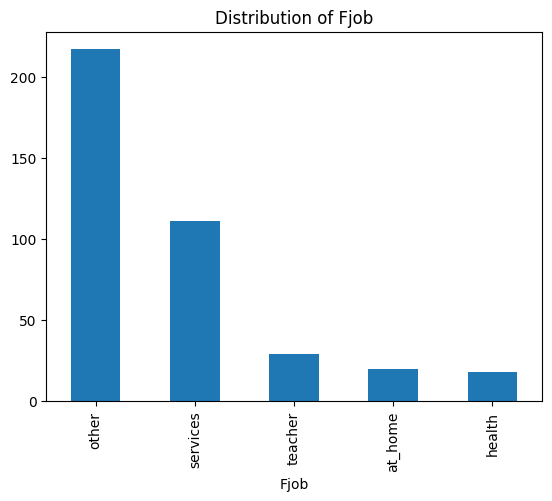

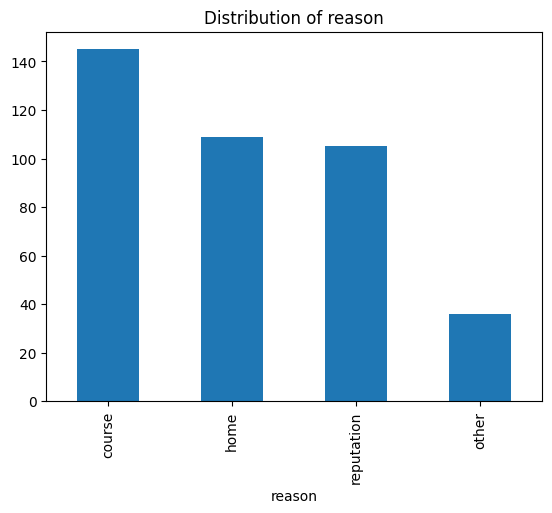

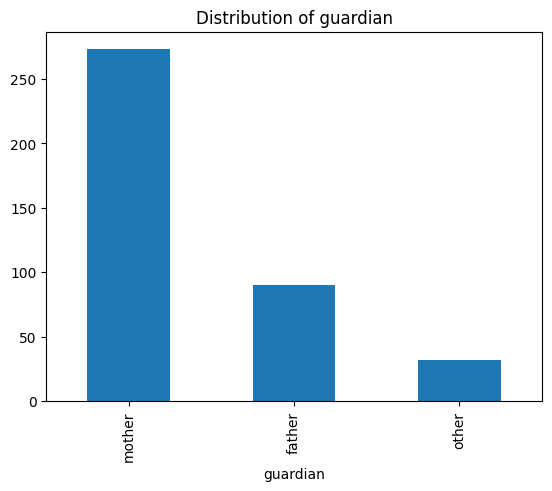

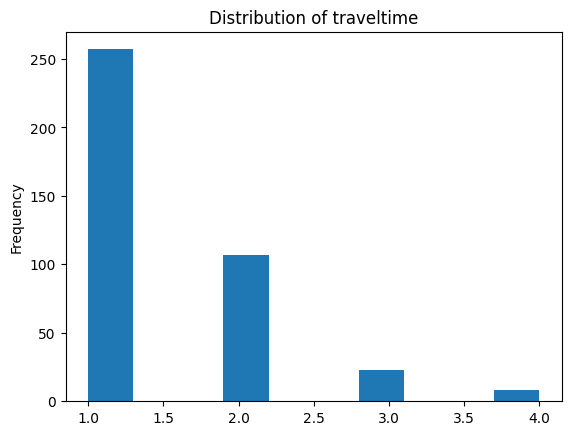

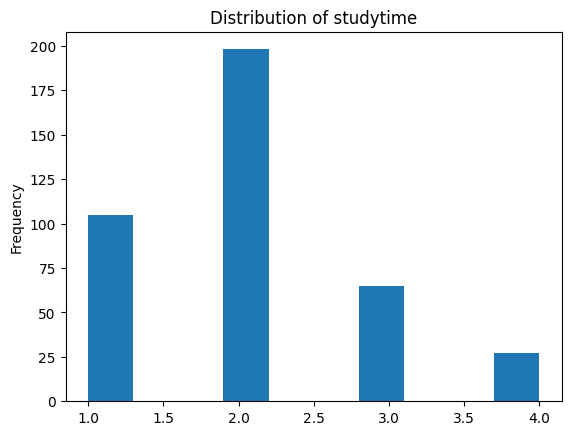

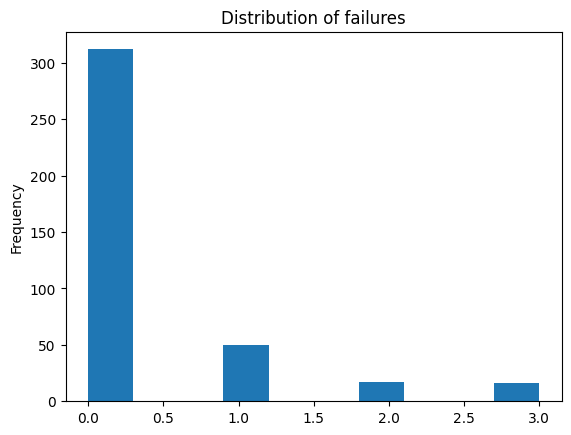

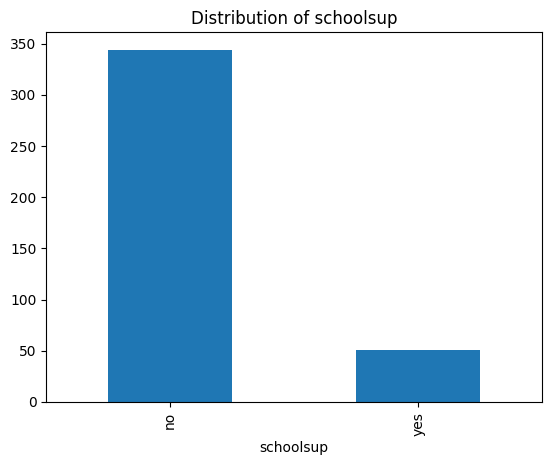

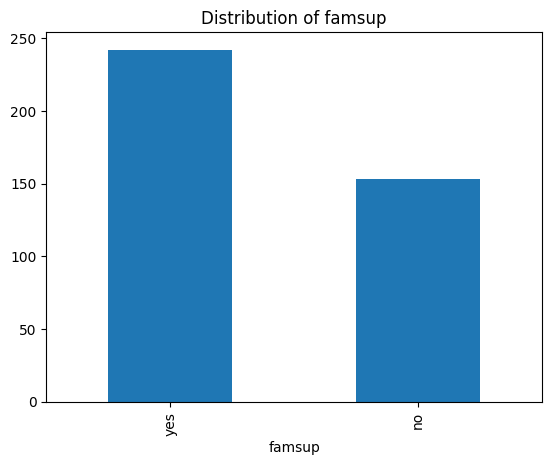

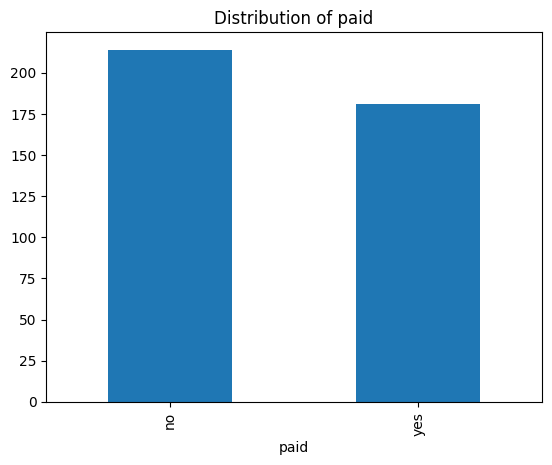

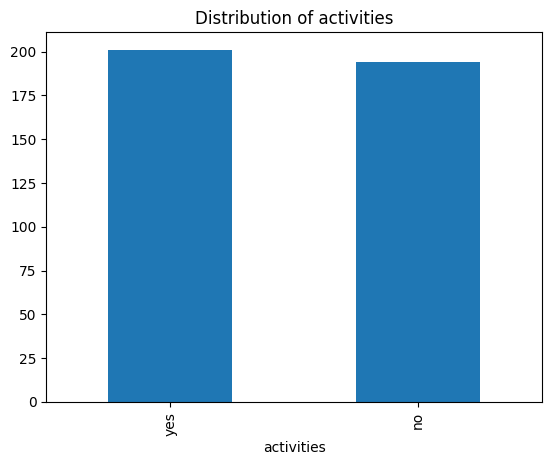

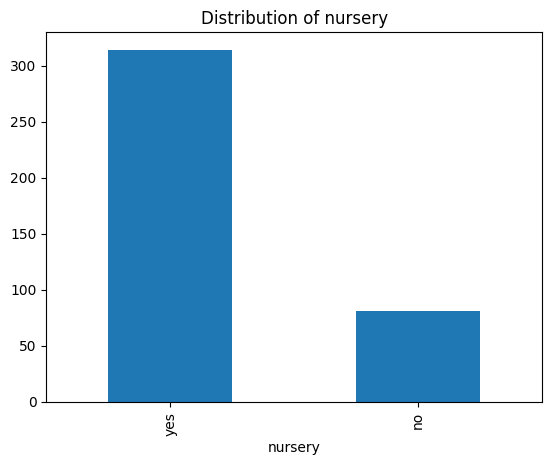

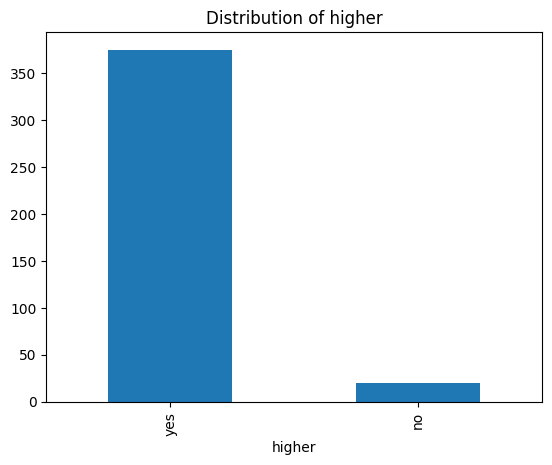

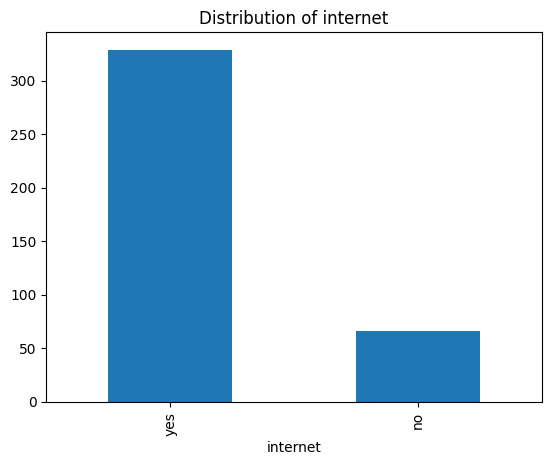

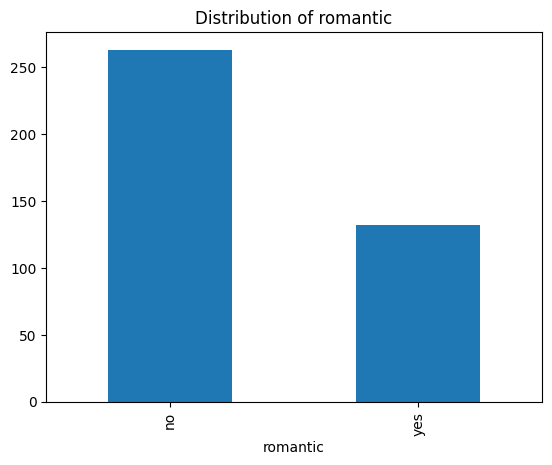

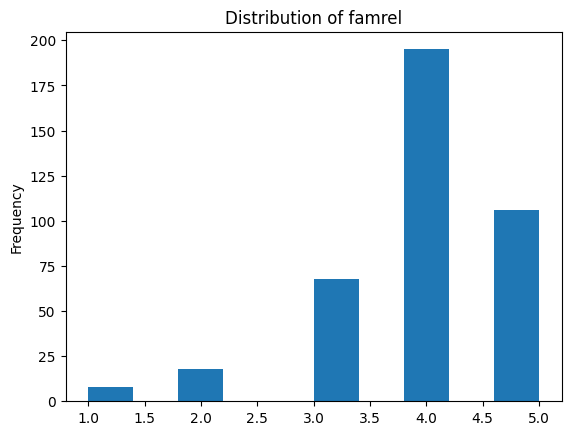

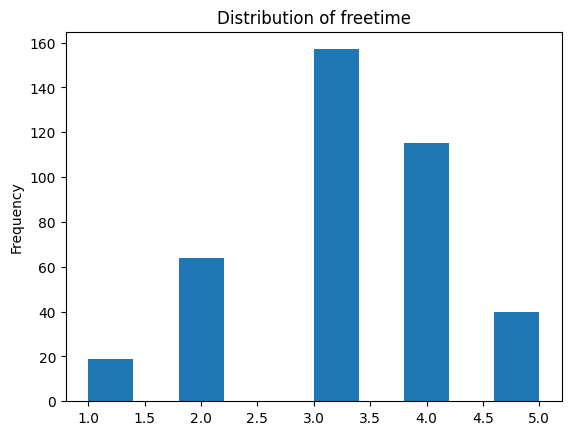

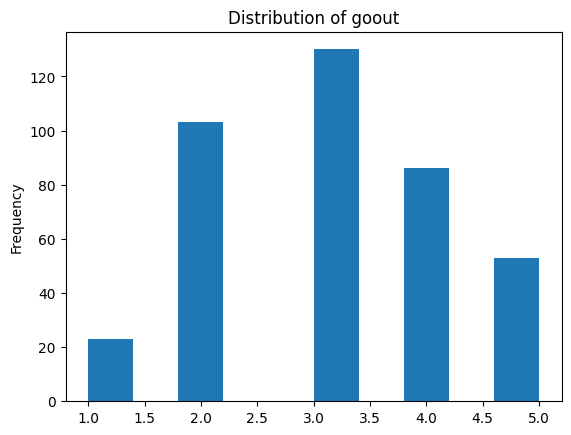

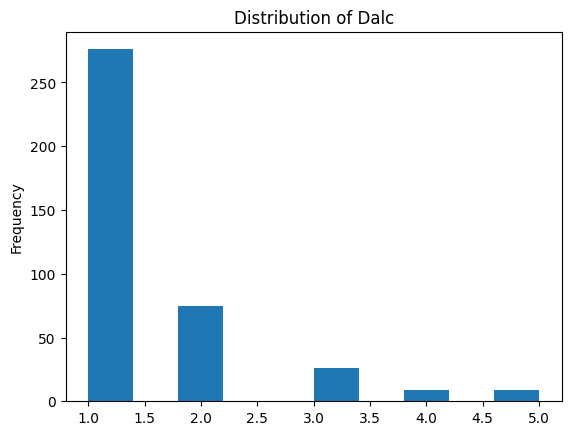

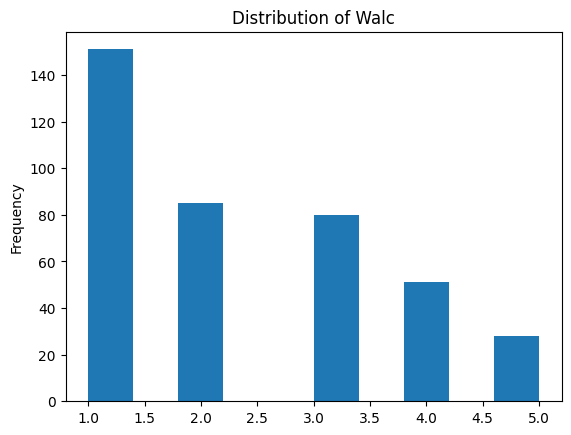

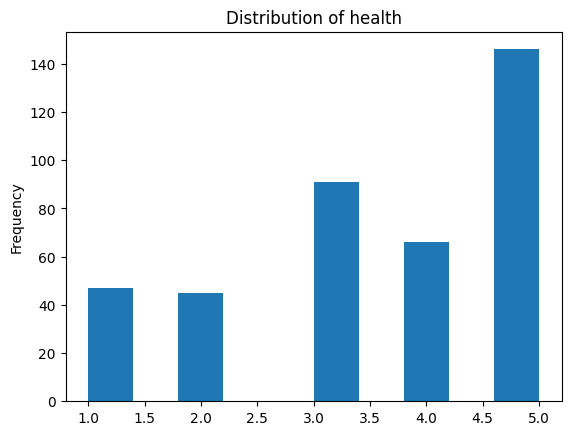

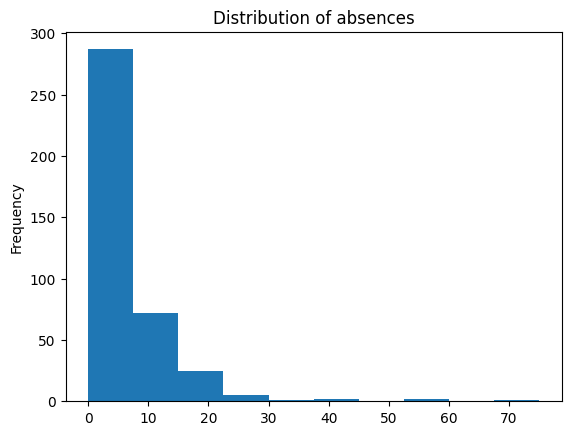

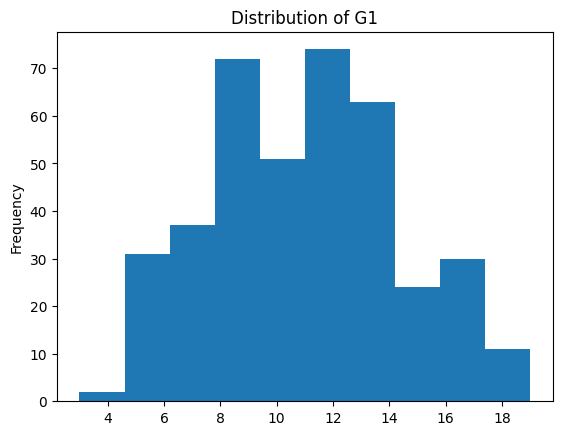

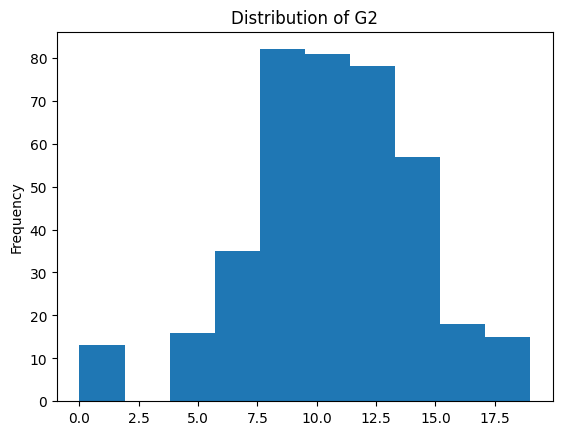

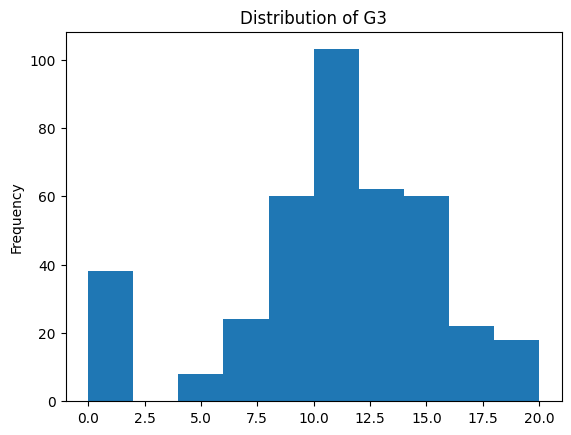

In [13]:
columns = list(case_study.columns)
for i in columns:
    plt.figure()
    if case_study[i].dtype == object:
        case_study[i].value_counts().plot(kind="bar")
    else:
        case_study[i].plot(kind="hist")
    plt.title(f"Distribution of {i}") 
    
    plt.show()


<Axes: >

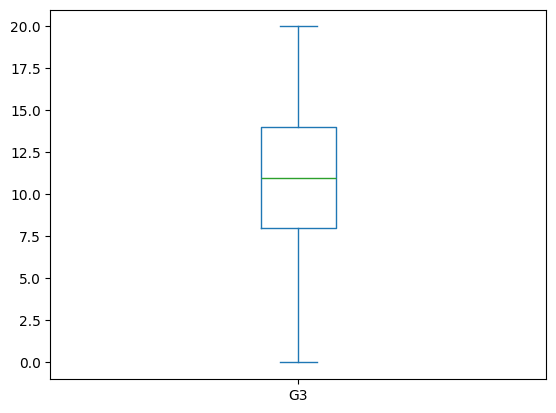

In [14]:
case_study['G3'].plot(kind='box')

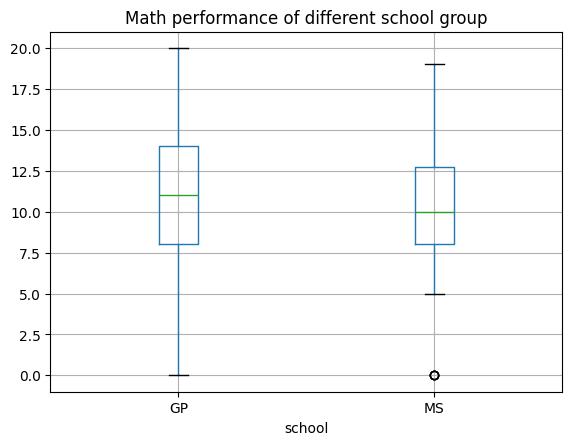

p-value: 0.3431


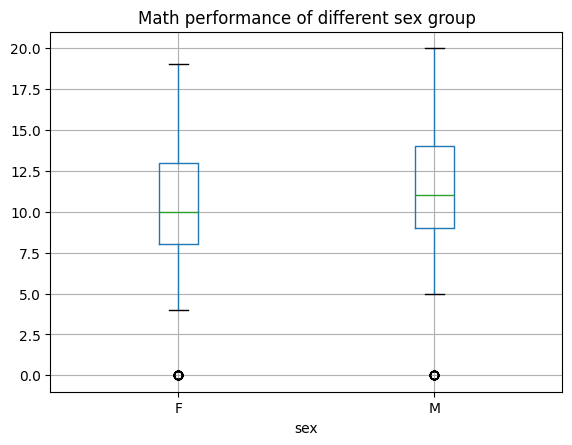

p-value: 0.0396
the means of the two groups are significantly different from each other


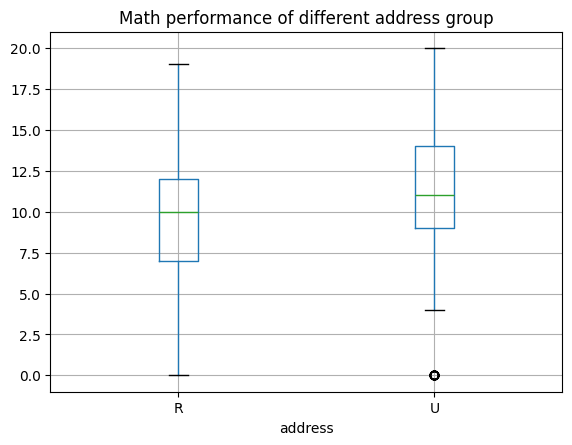

p-value: 0.0366
the means of the two groups are significantly different from each other


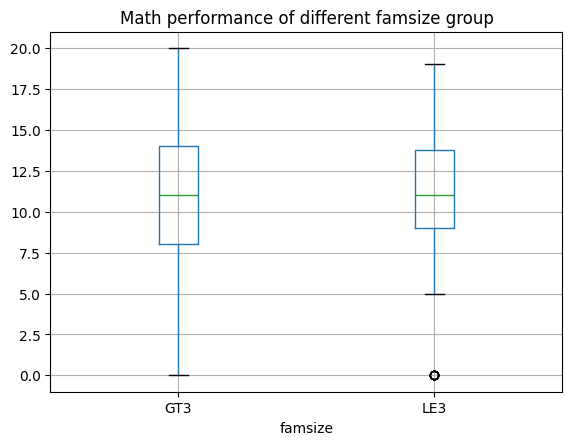

p-value: 0.0916


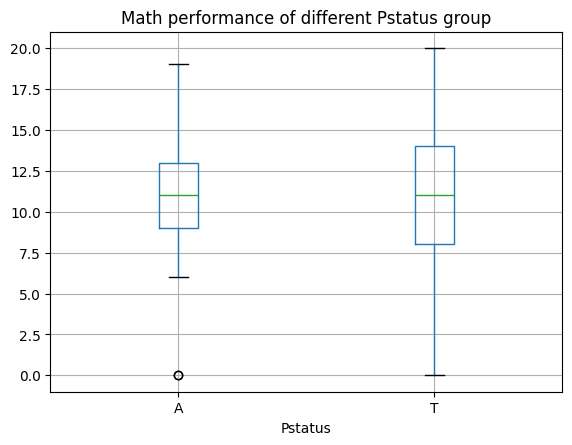

p-value: 0.2282


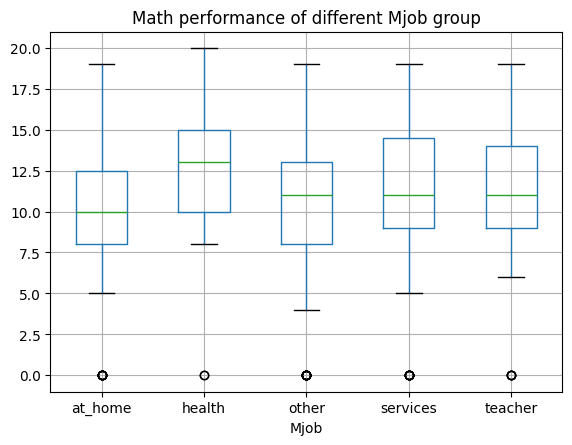

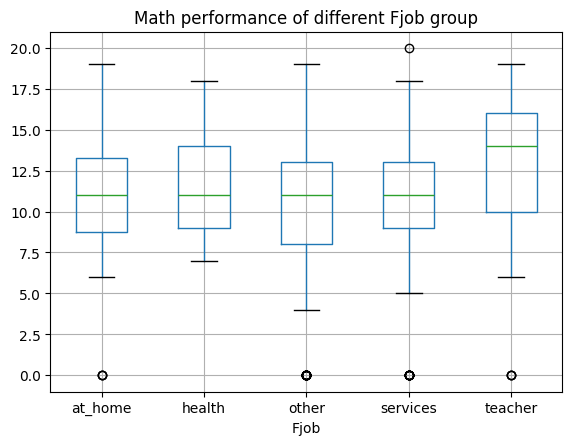

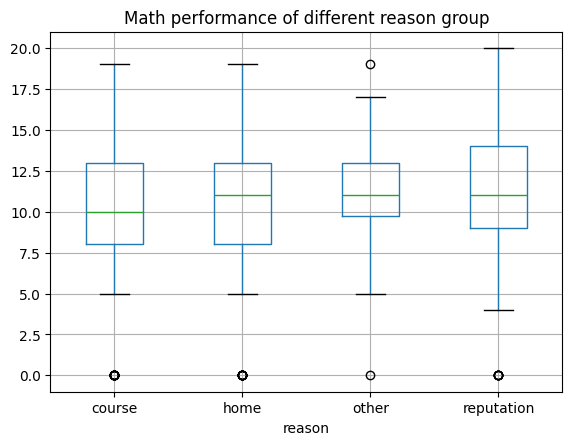

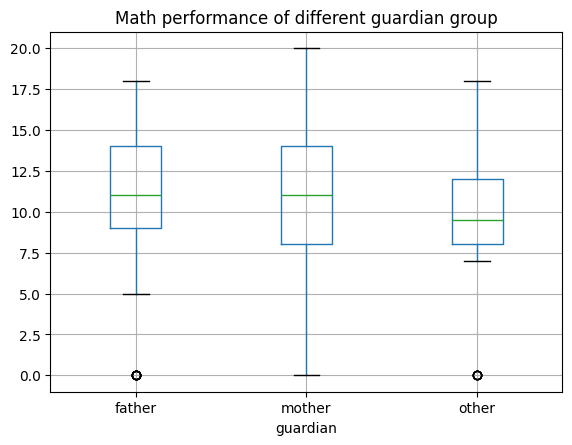

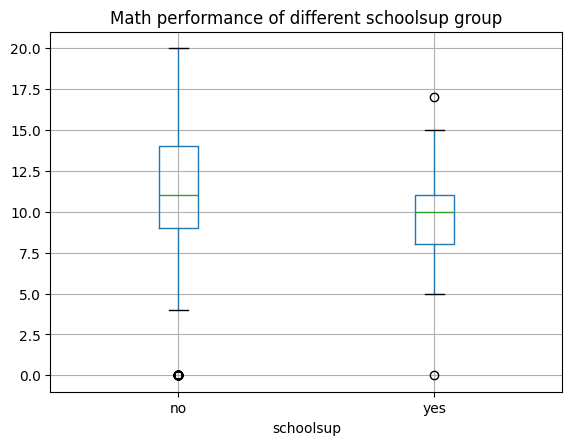

p-value: 0.0197
the means of the two groups are significantly different from each other


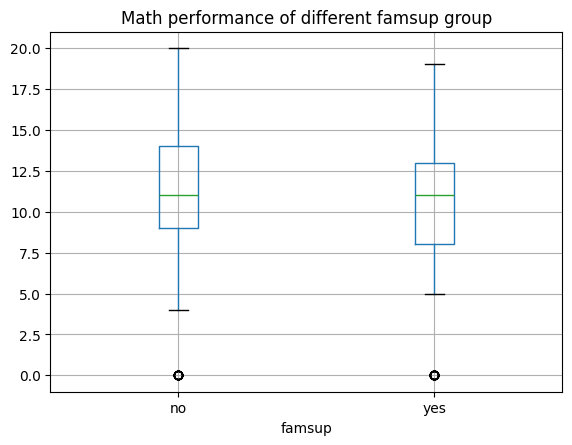

p-value: 0.4398


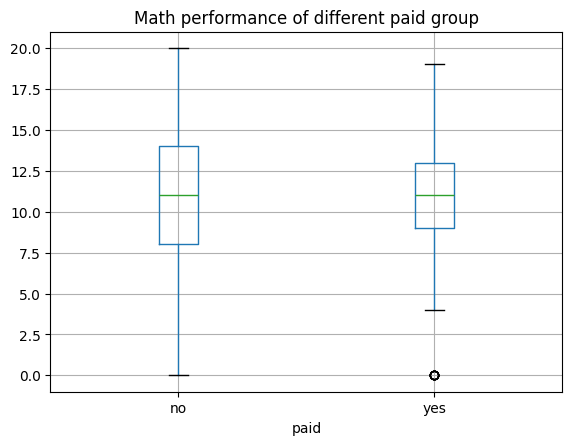

p-value: 0.0379
the means of the two groups are significantly different from each other


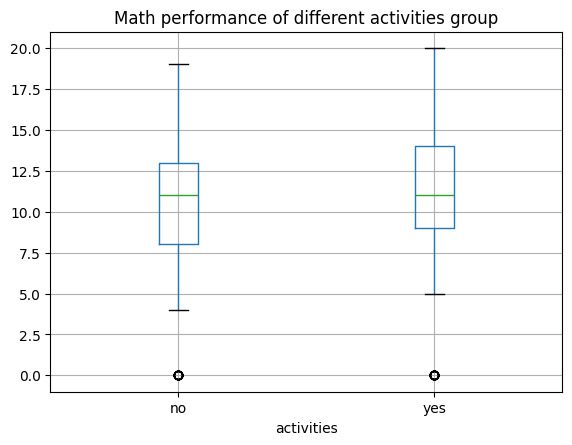

p-value: 0.7496


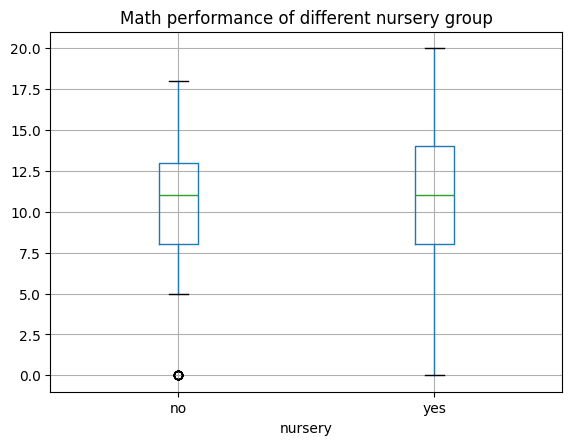

p-value: 0.3064


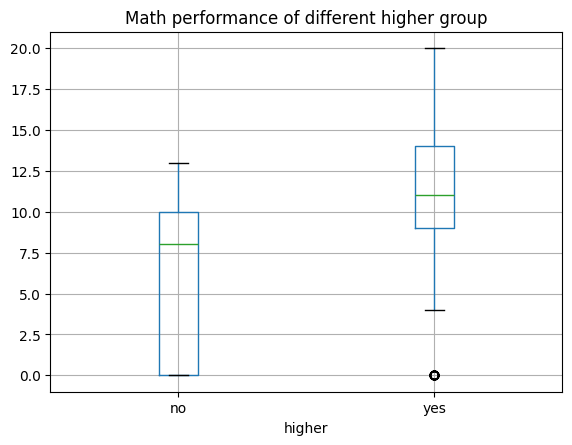

p-value: 0.0024
the means of the two groups are significantly different from each other


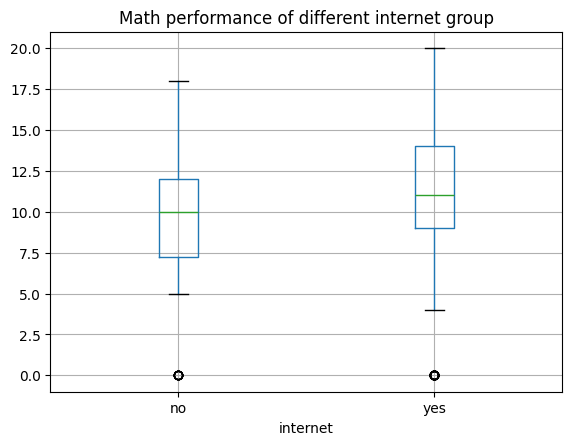

p-value: 0.0496
the means of the two groups are significantly different from each other


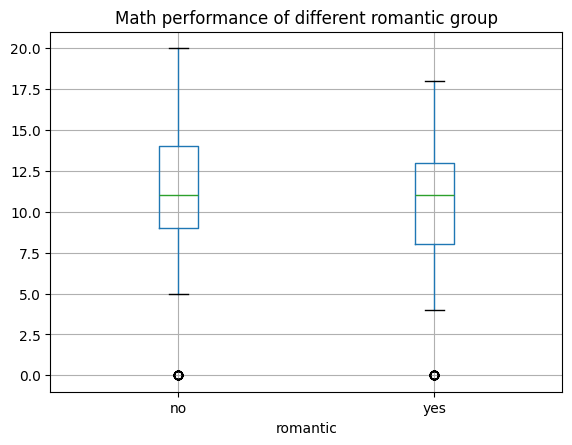

p-value: 0.0127
the means of the two groups are significantly different from each other
           Effect_Size
paid          0.936671
sex           0.948092
schoolsup     1.129674
address       1.162903
internet      1.207930
romantic      1.260744
higher        3.808000


In [15]:
columns = list(case_study.columns)
check = ['absences','G1','G2']
effect_size_features = pd.DataFrame()
for c_name in columns:
    if case_study[c_name].name not in check and c_name != 'G3':
        if case_study[c_name].dtype == object:
            unique = list(case_study[c_name].unique())
            group = case_study.groupby(c_name)
            
            case_study.boxplot(column='G3', by=c_name)
            plt.title(f'Math performance of different {c_name} group')
            plt.suptitle('')
            plt.show()
            if len(unique)<=2:
                group_A = group.get_group(unique[0])
                group_B = group.get_group(unique[1])
                t_stat, p_value = stats.ttest_ind(group_A['G3'], group_B['G3'], equal_var=False)
                print(f"p-value: {p_value:.4f}")
                if p_value < 0.05:
                    print("the means of the two groups are significantly different from each other")
                    effect_size = abs(group_A['G3'].mean()-group_B['G3'].mean())
                    effect_size_features.loc[c_name, 'Effect_Size'] = effect_size
                
    else:
        pass
print(effect_size_features.sort_values(by="Effect_Size"))

<Axes: title={'center': 'Effect_size of mean difference'}, xlabel='feature', ylabel='mean difference'>

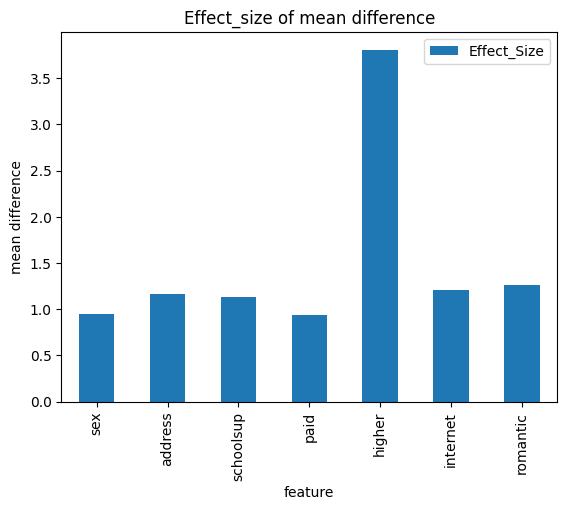

In [17]:
effect_size_features.plot(kind='bar', title="Effect_size of mean difference", ylabel='mean difference', xlabel='feature')

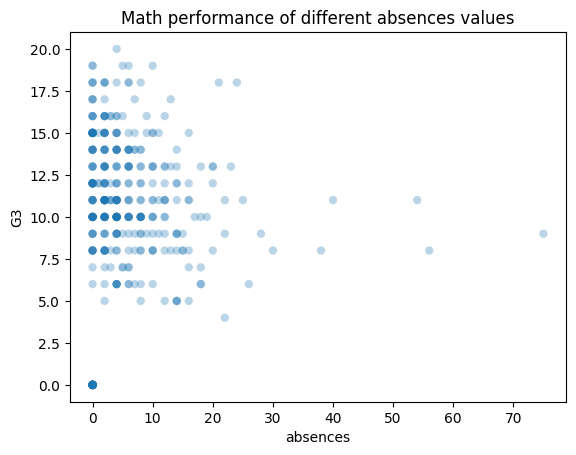

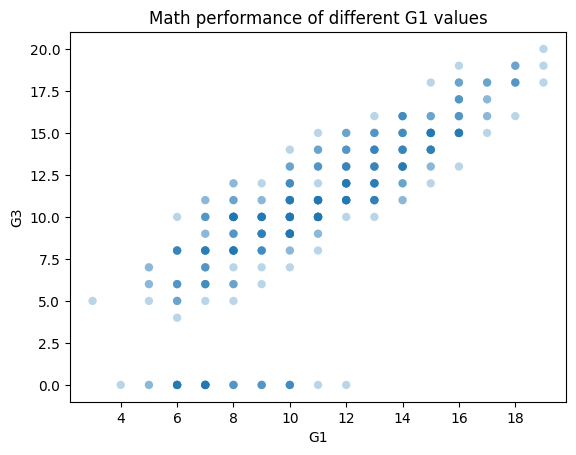

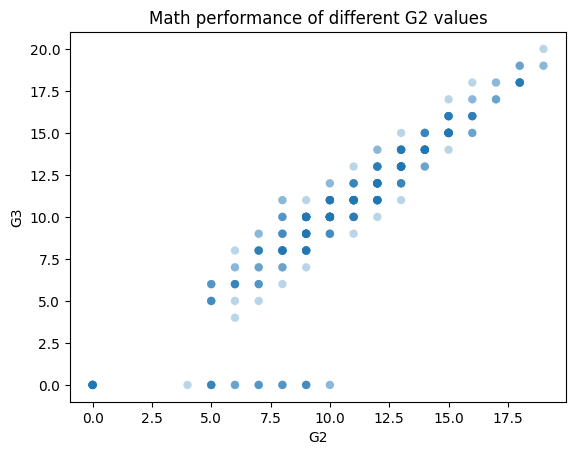

In [18]:
columns = list(case_study.columns)
check = ['absences','G1','G2']
for c_name in columns:
    if case_study[c_name].dtype == 'int64' and case_study[c_name].name in check and c_name != 'G3':
        plt.scatter(x=case_study[c_name], y=case_study['G3'], alpha=0.3, edgecolors='none')
        plt.title(f'Math performance of different {c_name} values')
        plt.xlabel(f"{c_name}")
        plt.ylabel("G3")
        plt.suptitle('')
        plt.show()

    else:
        pass

# 4. Identify Key Drivers


For binary features: The largerest effect size is higher, the second is romantic and the third is internet. All with statistics significance different, given the effect_size ranking
For continuous features: it's obvious that G1 values and G2 values have a positive linear relationship
For mutiple features: jobtype feature that teacher have higher mean than other feature in math performance by observation


# **XGBoost prediction**

In [ ]:
pip install eli5


In [29]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error 
from xgboost import XGBRegressor   
import eli5
from eli5.sklearn import PermutationImportance

X = case_study.iloc[:, :-1].copy()  # 使用 .copy() 避免隱性警告
y = case_study.iloc[:, -1]  

for col in X.select_dtypes(include=['object', 'category']).columns:
    X[col] = X[col].fillna('Missing').astype(str)

X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded = X_encoded.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42)

xgboostModel = XGBRegressor(n_estimators=100, learning_rate=0.3, random_state=42)
xgboostModel.fit(X_train, y_train)

y_train_pred = xgboostModel.predict(X_train)
y_test_pred = xgboostModel.predict(X_test)

print('Train R2 Score: ', xgboostModel.score(X_train, y_train))
print('Test R2 Score: ', xgboostModel.score(X_test, y_test))
print('Train MAE: ', mean_absolute_error(y_train, y_train_pred))
print('Test MAE: ', mean_absolute_error(y_test, y_test_pred))

print("\n--- 計算特徵重要性 ---")
perm = PermutationImportance(xgboostModel, random_state=1).fit(X_test, y_test)
eli5.show_weights(perm, feature_names=X_test.columns.tolist())




Train R2 Score:  0.9999999403953552
Test R2 Score:  0.8483250737190247
Train MAE:  0.0007513209711760283
Test MAE:  1.088498830795288

--- 計算特徵重要性 ---


Weight,Feature
1.6834 ± 0.6223,G2
0.1733 ± 0.0809,absences
0.0248 ± 0.0129,famrel
0.0144 ± 0.0323,age
0.0106 ± 0.0078,G1
0.0095 ± 0.0098,health
0.0041 ± 0.0011,studytime
0.0039 ± 0.0045,activities_yes
0.0020 ± 0.0030,Mjob_services
0.0019 ± 0.0024,internet_yes
